In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/adhee/INFOSYS/Milestones/Milestone1/data/Clean-Data")
df

,timestamp,fridge,ac,lights,microwave,total_power
0,2023-01-01 00:00:00,0,0,28,0,28.0
1,2023-01-01 01:00:00,119,0,84,0,203.0
2,2023-01-01 02:00:00,135,0,47,0,182.0
3,2023-01-01 03:00:00,171,0,21,0,192.0
4,2023-01-01 04:00:00,0,0,88,0,88.0
...,...,...,...,...,...,...
4316,2023-06-29 20:00:00,146,2221,23,0,2390.0
4317,2023-06-29 21:00:00,72,1887,31,0,1990.0
4318,2023-06-29 22:00:00,156,1982,0,0,2138.0
4319,2023-06-29 23:00:00,149,1143,43,0,1335.0


In [12]:
target_col = df_clean['total_power']

In [13]:
df['time'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['time'].dt.hour
df['month'] = df['time'].dt.month


In [14]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)


In [15]:
# Month cyclic encoding (12 months)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [19]:
df.head()

,timestamp,fridge,ac,lights,microwave,total_power,hour,month,hour_sin,hour_cos,month_sin,month_cos
time,,,,,,,,,,,,
2023-01-01 00:00:00,2023-01-01 00:00:00,0,0,28,0,28.0,0,1,0.000000,1.000000,0.5,0.866025
2023-01-01 01:00:00,2023-01-01 01:00:00,119,0,84,0,203.0,1,1,0.258819,0.965926,0.5,0.866025
2023-01-01 02:00:00,2023-01-01 02:00:00,135,0,47,0,182.0,2,1,0.500000,0.866025,0.5,0.866025
2023-01-01 03:00:00,2023-01-01 03:00:00,171,0,21,0,192.0,3,1,0.707107,0.707107,0.5,0.866025
2023-01-01 04:00:00,2023-01-01 04:00:00,0,0,88,0,88.0,4,1,0.866025,0.500000,0.5,0.866025


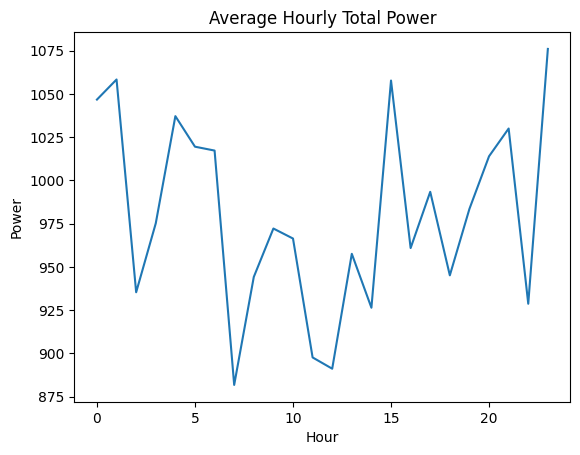

In [20]:
hourly_pattern = df.groupby('hour')['total_power'].mean()
import matplotlib.pyplot as plt
hourly_pattern.plot()
plt.title("Average Hourly Total Power")
plt.xlabel("Hour")
plt.ylabel("Power")
plt.show()

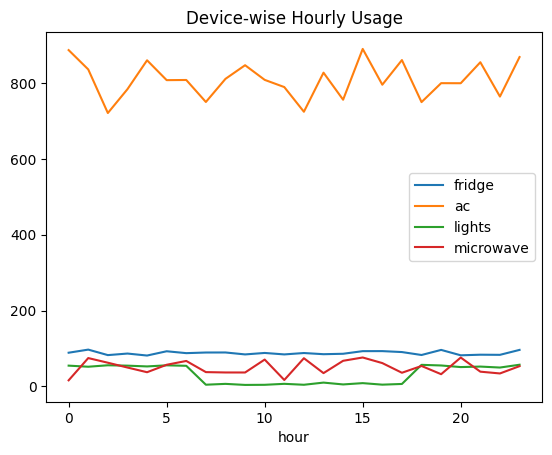

In [21]:
device_hourly = df.groupby('hour')[['fridge','ac','lights','microwave']].mean()
device_hourly.plot()
plt.title("Device-wise Hourly Usage")
plt.show()